# Medical Image Processing: Final Project
## Einar López Altamirano

# Task 2: 3D Rigid Coregistration

## Libraries

In [25]:
import pydicom
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from pathlib import Path
import itk
from scipy.ndimage import rotate

## Task 2A: Coregistration

### MR Inspection

In [2]:
MR_PATH  = Path('data/15252129_s1_AX_3D_T1__C_FSPGR_FORISI260916')

In [13]:
mr_itk = itk.imread(str(MR_PATH), itk.F)

print(f"Largest Possible Region Shape: {mr_itk.GetLargestPossibleRegion().GetSize()}")
print(f"Spacing: {mr_itk.GetSpacing()}")
print(f"Origin: {mr_itk.GetOrigin()}")
print(f"Direction: {mr_itk.GetDirection()}")


Largest Possible Region Shape: itkSize3 ([256, 256, 156])
Spacing: itkVectorD3 ([1, 1, 1])
Origin: itkPointD3 ([-127.054, -169.357, -75.0121])
Direction: itkMatrixD33 ([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]])


### MR Visualization

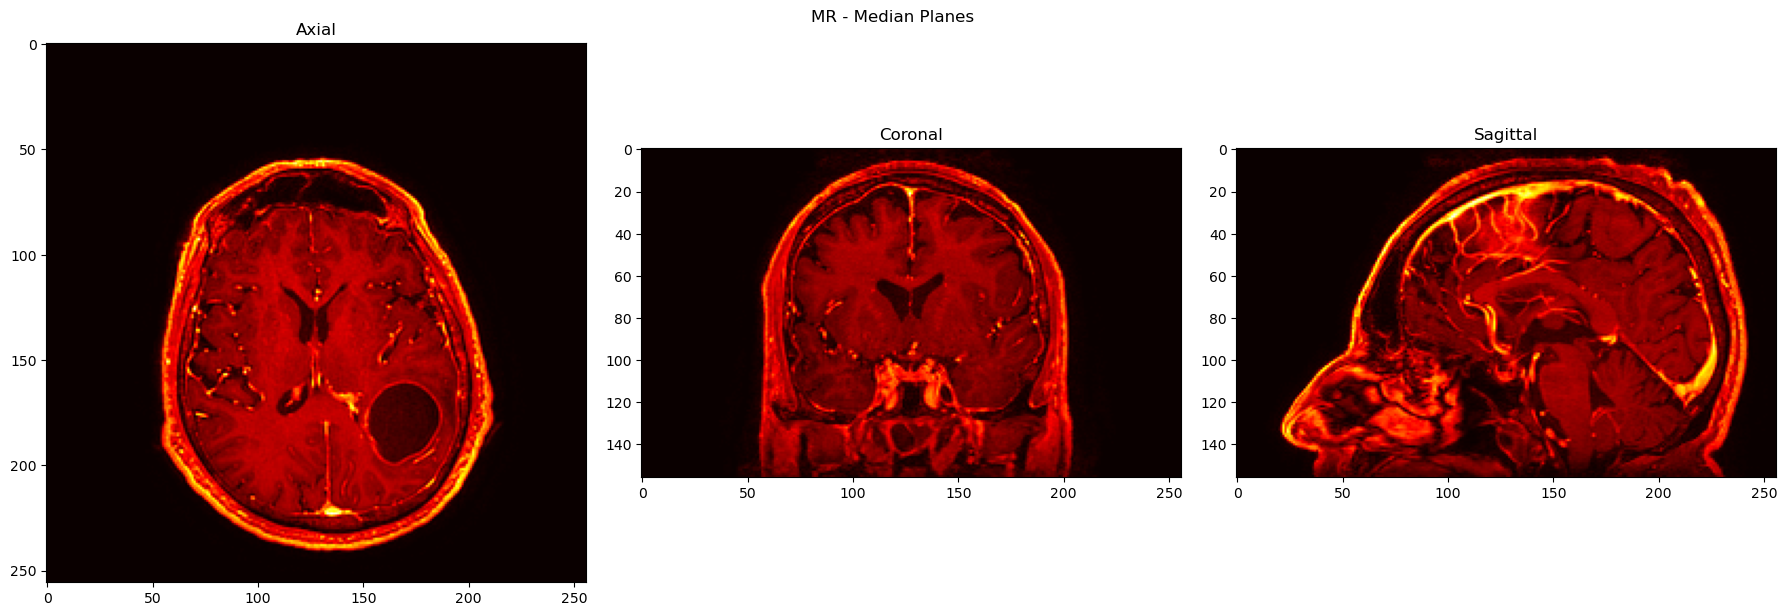

In [ ]:
spacing_between_slices = float(mr_itk.GetSpacing()[0])  
rows = mr_itk.GetLargestPossibleRegion().GetSize()[0]   
cols = mr_itk.GetLargestPossibleRegion().GetSize()[1]    

arr = itk.array_from_image(mr_itk)
nz, ny, nx = arr.shape

# ONLY FOR VISUALIZATION
axial    = arr[nz//2]
coronal  = arr[::-1, ny//2, :]
sagittal = arr[::-1, :, nx//2]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'MR - Median Planes ')

axes[0].imshow(axial,    cmap='hot', aspect='equal')
axes[0].set_title('Axial')

axes[1].imshow(coronal,  cmap='hot', aspect='equal')
axes[1].set_title('Coronal')

axes[2].imshow(sagittal,  cmap='hot', aspect='equal')
axes[2].set_title('Sagittal')

plt.tight_layout()
plt.show()

### PET Inspection

In [15]:
pet_mean_itk  = itk.imread('./data/processed/mean_pet.mha', itk.F)
pet_last_frame_itk = itk.imread('./data/processed/last_frame_pet.mha', itk.F)

In [16]:
print(f"Largest Possible Region Shape: {pet_mean_itk.GetLargestPossibleRegion().GetSize()}")
print(f"Spacing: {pet_mean_itk.GetSpacing()}")
print(f"Origin: {pet_mean_itk.GetOrigin()}")
print(f"Direction: {pet_mean_itk.GetDirection()}")

Largest Possible Region Shape: itkSize3 ([256, 256, 47])
Spacing: itkVectorD3 ([1.17188, 1.17188, 3.27])
Origin: itkPointD3 ([-149.414, -149.414, -170.42])
Direction: itkMatrixD33 ([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]])


In [17]:
print(f"Largest Possible Region Shape: {pet_last_frame_itk.GetLargestPossibleRegion().GetSize()}")
print(f"Spacing: {pet_last_frame_itk.GetSpacing()}")
print(f"Origin: {pet_last_frame_itk.GetOrigin()}")
print(f"Direction: {pet_last_frame_itk.GetDirection()}")

Largest Possible Region Shape: itkSize3 ([256, 256, 47])
Spacing: itkVectorD3 ([1.17188, 1.17188, 3.27])
Origin: itkPointD3 ([-149.414, -149.414, -170.42])
Direction: itkMatrixD33 ([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]])


### Elastix Parameter Object

In [18]:
parameter_object = itk.ParameterObject.New()

# "rigid" preset
parameter_map = parameter_object.GetDefaultParameterMap('rigid')

# 6-DOF rigid transform: 3 rotations + 3 translations
parameter_map['Transform'] = ['EulerTransform']

# Multimodal-safe similarity metric
parameter_map['Metric'] = ['AdvancedMattesMutualInformation']

# Aligning the volume centers -> ~(0, −42, +97) mm offset
parameter_map['AutomaticTransformInitialization']       = ['true']
parameter_map['AutomaticTransformInitializationMethod'] = ['GeometricalCenter']

parameter_object.AddParameterMap(parameter_map)

print(parameter_object)

ParameterObject (0x31e7dd420)
  RTTI typeinfo:   elastix::ParameterObject
  Reference Count: 1
  Modified Time: 33619
  Debug: Off
  Object Name: 
  Observers: 
    none
ParameterMap 0: 
  (AutomaticParameterEstimation "true")
  (AutomaticScalesEstimation "true")
  (AutomaticTransformInitialization "true")
  (AutomaticTransformInitializationMethod "GeometricalCenter")
  (CheckNumberOfSamples "true")
  (DefaultPixelValue 0)
  (FinalBSplineInterpolationOrder 3)
  (FixedImagePyramid "FixedSmoothingImagePyramid")
  (ImageSampler "RandomCoordinate")
  (Interpolator "LinearInterpolator")
  (MaximumNumberOfIterations 256)
  (MaximumNumberOfSamplingAttempts 8)
  (Metric "AdvancedMattesMutualInformation")
  (MovingImagePyramid "MovingSmoothingImagePyramid")
  (NewSamplesEveryIteration "true")
  (NumberOfResolutions 4)
  (NumberOfSamplesForExactGradient 4096)
  (NumberOfSpatialSamples 2048)
  (Optimizer "AdaptiveStochasticGradientDescent")
  (Registration "MultiResolutionRegistration")
  (Resamp

### Elastix Registration

In [19]:
registered_image, result_transform  = itk.elastix_registration_method(mr_itk, pet_mean_itk, parameter_object=parameter_object)

In [20]:
print("Registration Shape: ", itk.array_from_image(registered_image).shape, "\n")
print(f"Result Transform: {result_transform}")

Registration Shape:  (156, 256, 256) 

Result Transform: ParameterObject (0x31e7ea330)
  RTTI typeinfo:   elastix::ParameterObject
  Reference Count: 1
  Modified Time: 65571
  Debug: Off
  Object Name: 
  Observers: 
    none
ParameterMap 0: 
  (CenterOfRotationPoint 0.44599999999999795 -41.857 2.4878999999999962)
  (CompressResultImage "false")
  (ComputeZYX "false")
  (DefaultPixelValue 0)
  (Direction 1 0 0 0 1 0 0 0 1)
  (FinalBSplineInterpolationOrder 3)
  (FixedImageDimension 3)
  (FixedInternalImagePixelType "float")
  (HowToCombineTransforms "Compose")
  (Index 0 0 0)
  (InitialTransformParameterFileName "NoInitialTransform")
  (MovingImageDimension 3)
  (MovingInternalImagePixelType "float")
  (NumberOfParameters 6)
  (Origin -127.054 -169.357 -75.0121)
  (ResampleInterpolator "FinalBSplineInterpolator")
  (Resampler "DefaultResampler")
  (ResultImageFormat "nii")
  (ResultImagePixelType "float32")
  (Size 256 256 156)
  (Spacing 1 1 1)
  (Transform "EulerTransform")
  (Trans

## Task 2B: Coregistration Visualization

### Alpha Fusion

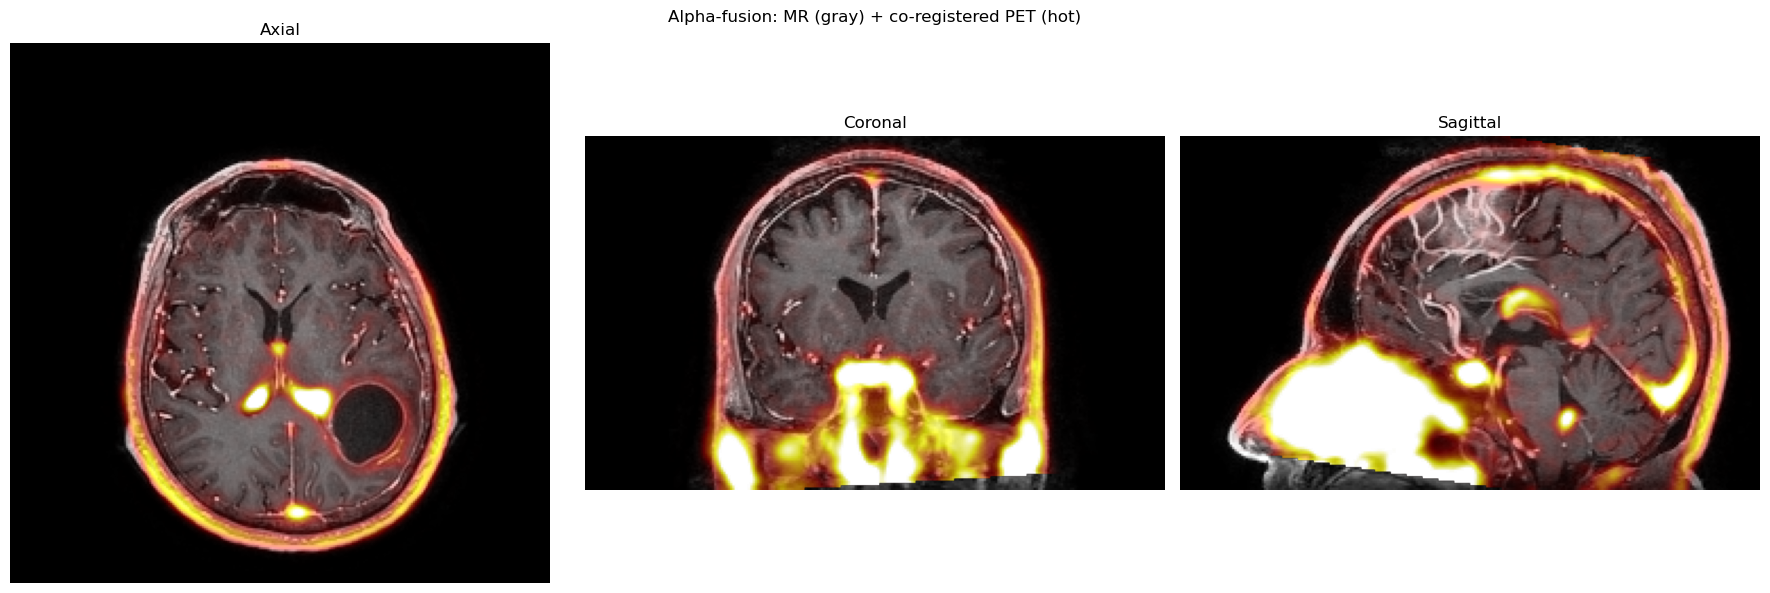

In [ ]:

mr_arr  = itk.array_from_image(mr_itk)           
pet_arr = itk.array_from_image(registered_image)

def normalize(vol, p=99):
    vmax = np.percentile(vol, p)
    return np.clip(vol / vmax, 0, 1) if vmax > 0 else vol

mr_n  = normalize(mr_arr)
pet_n = normalize(pet_arr)

nz, ny, nx = mr_arr.shape
planes = {
    'Axial':    (mr_n[nz // 2],          pet_n[nz // 2]),
    'Coronal':  (mr_n[::-1, ny // 2, :], pet_n[::-1, ny // 2, :]),
    'Sagittal': (mr_n[::-1, :, nx // 2], pet_n[::-1, :, nx // 2]),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Alpha-fusion: MR (gray) + co-registered PET (hot)')

for ax, (name, (mr_s, pet_s)) in zip(axes, planes.items()):
    ax.imshow(mr_s, cmap='gray')
    ax.imshow(pet_s, cmap='hot', alpha=pet_s)
    ax.set_title(name)
    ax.axis('off')

plt.tight_layout()
plt.savefig('./results_task2/alpha_fusion_check.png', dpi=100, bbox_inches='tight')
plt.show()

### Animation Generation

In [ ]:

mr_vol  = itk.array_from_image(mr_itk)           
pet_vol = itk.array_from_image(registered_image)  

mr_vmax  = np.percentile(mr_vol.max(axis=1),  99)
pet_vmax = np.percentile(pet_vol.max(axis=1), 99)

n_frames = 72                                  
angles   = np.linspace(0, 360, n_frames, endpoint=False)

def mip_at(vol, angle):
    """Rotate the volume around z, then MIP along the (rotated) y axis."""
    rotated = rotate(vol, angle, axes=(1, 2), reshape=False, order=1)
    return rotated.max(axis=1)                      

frames_gif = []
for i, angle in enumerate(angles):
    mr_mip  = mip_at(mr_vol,  angle)
    pet_mip = mip_at(pet_vol, angle)

    mr_n  = np.clip(mr_mip  / mr_vmax,  0, 1)[::-1]
    pet_n = np.clip(pet_mip / pet_vmax, 0, 1)[::-1]

    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    fig.suptitle(f'Rotating MIP — {angle:.0f}°')

    axes[0].imshow(mr_n, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title('MR (reference)')

    axes[1].imshow(pet_n, cmap='hot', vmin=0, vmax=1)
    axes[1].set_title('Co-registered PET')

    axes[2].imshow(mr_n, cmap='gray', vmin=0, vmax=1)
    axes[2].imshow(pet_n, cmap='hot', alpha=pet_n, vmin=0, vmax=1)
    axes[2].set_title('Alpha-fusion')

    for ax in axes:
        ax.axis('off')
    plt.tight_layout()

    fig.canvas.draw()
    frames_gif.append(np.asarray(fig.canvas.buffer_rgba())[:, :, :3])
    plt.close(fig)

    if i % 10 == 0:
        print(f'  Rendered frame {i+1}/{n_frames}')

imageio.mimsave('./results_task2/rotating_mip.gif', frames_gif, fps=10)
print('GIF saved to ./results_task2/rotating_mip.gif')

  Rendered frame 1/72
  Rendered frame 11/72
  Rendered frame 21/72
  Rendered frame 31/72
  Rendered frame 41/72
  Rendered frame 51/72
  Rendered frame 61/72
  Rendered frame 71/72
GIF saved to ./results_task2/rotating_mip.gif


## Data Export For Task 2 and 3

In [29]:
print(f'Number of parameter maps: {result_transform.GetNumberOfParameterMaps()}')

result_transform.WriteParameterFile(
    'data/processed/registration_transform.txt',
)

Number of parameter maps: 1
